# Unemployment Analysis with Python

**Objective:** Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

**Author:** Prajna K V

## 1. Load the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("unemployment_data.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,Longitude,Latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 2. Data Cleaning

The raw dataset has a duplicate column name (`Region` appears twice — one is the state, one is the geographic zone), extra whitespace in column names, and the `Date` column is stored as text rather than an actual date.

In [2]:
# Clean column names
df.columns = df.columns.str.strip()

# Rename for clarity
df = df.rename(columns={
    "Region": "State",
    "Region.1": "Zone",
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate"
})

# Convert Date to a real datetime type
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Zone,Longitude,Latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (267, 9)
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   State                      267 non-null    str           
 1   Date                       267 non-null    datetime64[us]
 2   Frequency                  267 non-null    str           
 3   Unemployment_Rate          267 non-null    float64       
 4   Employed                   267 non-null    int64         
 5   Labour_Participation_Rate  267 non-null    float64       
 6   Zone                       267 non-null    str           
 7   Longitude                  267 non-null    float64       
 8   Latitude                   267 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memory usage: 18.9 KB


In [4]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Longitude,Latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [5]:
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Number of states:", df['State'].nunique())

Date range: 2020-01-31 00:00:00 to 2020-10-31 00:00:00
Number of states: 27


**Observation:** The dataset has no missing values across all 267 rows. It covers 27 Indian states from January 2020 to October 2020 — a window that captures the COVID-19 lockdown period.

## 4. Time-Series Analysis: Unemployment Trends Over Time

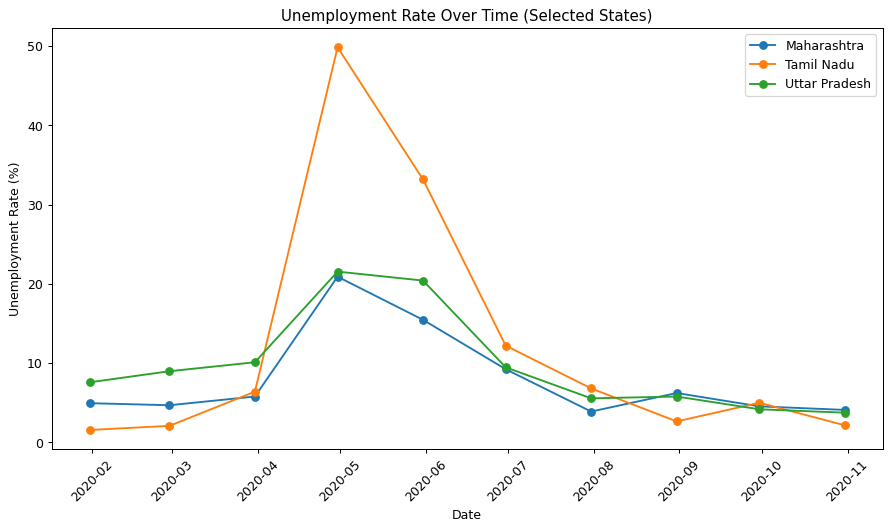

In [6]:
import matplotlib.pyplot as plt

states_to_plot = ["Maharashtra", "Tamil Nadu", "Uttar Pradesh"]

plt.figure(figsize=(10, 6))
for state in states_to_plot:
    state_data = df[df["State"] == state].sort_values("Date")
    plt.plot(state_data["Date"], state_data["Unemployment_Rate"], marker="o", label=state)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time (Selected States)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** All three states show a sharp spike in unemployment around April-May 2020, coinciding with India's COVID-19 lockdown, followed by a gradual recovery through the rest of 2020.

## 5. Top 10 States by Average Unemployment Rate

State
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Unemployment_Rate, dtype: float64


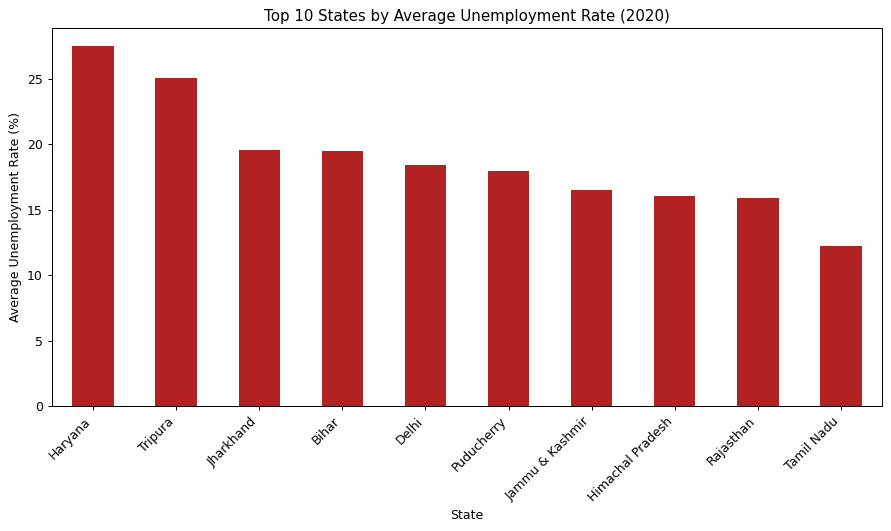

In [7]:
avg_by_state = df.groupby("State")["Unemployment_Rate"].mean().sort_values(ascending=False).head(10)
print(avg_by_state)

plt.figure(figsize=(10, 6))
avg_by_state.plot(kind="bar", color="firebrick")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Top 10 States by Average Unemployment Rate (2020)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Haryana and Tripura recorded the highest average unemployment rates in 2020, both well above 25% on average — significantly higher than the national trend.

## 6. Correlation Heatmap

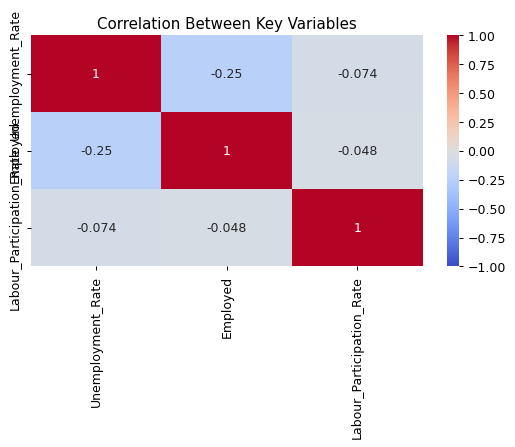

In [8]:
import seaborn as sns

corr_cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Key Variables")
plt.tight_layout()
plt.show()

**Observation:** Unemployment Rate shows a weak negative correlation with Employed (-0.25) and almost no linear correlation with Labour Participation Rate (-0.07), suggesting unemployment spikes were not strongly tied to people leaving the labour force, but rather to job losses among those still seeking work.

## 7. Pre-COVID vs Post-COVID Comparison

India's nationwide lockdown began on 25 March 2020. We split the data into Pre-Lockdown and Post-Lockdown periods to quantify the impact.

In [9]:
lockdown_start = pd.Timestamp("2020-03-25")
df["Period"] = df["Date"].apply(lambda d: "Pre-Lockdown" if d < lockdown_start else "Post-Lockdown")

comparison = df.groupby("Period")["Unemployment_Rate"].agg(["mean", "min", "max"])
comparison

,mean,min,max
Period,,,
Post-Lockdown,12.963860,0.50,75.85
Pre-Lockdown,9.231346,0.58,32.67


**Observation:** Average unemployment rose from 9.23% pre-lockdown to 12.96% post-lockdown — a roughly 40% relative increase. The maximum recorded rate jumped dramatically from 32.67% to 75.85%, reflecting extreme spikes in specific states during the peak lockdown months.

## 8. Conclusion & Business Recommendations

**Key Findings:**
1. The COVID-19 lockdown caused a sharp, temporary spike in unemployment across nearly all states, peaking around April-May 2020, with gradual recovery by autumn 2020.
2. Haryana and Tripura consistently recorded the highest average unemployment rates in 2020, indicating localized economic vulnerability beyond the national pandemic effect.
3. Employment levels and labour force participation were only weakly correlated with unemployment rate changes, suggesting job losses (not workforce exits) drove the unemployment spike.

**Recommendations:**
1. States like Haryana and Tripura should be prioritized for targeted employment support programs, as their elevated unemployment predates and outlasts the general pandemic trend.
2. Policymakers should prepare rapid-response employment schemes for future economic shocks, given how quickly unemployment spiked (within one month) and how long it took to normalize (several months).
3. Further investigation into sector-specific job losses (e.g., informal sector, manufacturing) in high-unemployment states could clarify targeted intervention areas.